In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import math 
import time 
import os
import sys 
import pathlib

In [2]:
df = pd.read_csv("/home/dhruv/Documents/NCF/NCF_Recommendation/NCF_Pytorch/train_data.csv")
df.head()

,UserID,ItemID,Rating,Timestamp
0,0,32,4,978824330
1,0,34,4,978824330
2,0,4,5,978824291
3,0,35,4,978824291
4,0,30,4,978824291


In [3]:
new_df = df.groupby("UserID").count().reset_index()
new_df

,UserID,ItemID,Rating,Timestamp
0,0,52,52,52
1,1,128,128,128
2,2,50,50,50
3,3,20,20,20
4,4,197,197,197
...,...,...,...,...
6035,6035,887,887,887
6036,6036,201,201,201
6037,6037,19,19,19
6038,6038,122,122,122


In [4]:
new_df["ItemID"].max()

np.int64(2313)

In [5]:
new_df.sort_values(["UserID", "Timestamp"])

,UserID,ItemID,Rating,Timestamp
0,0,52,52,52
1,1,128,128,128
2,2,50,50,50
3,3,20,20,20
4,4,197,197,197
...,...,...,...,...
6035,6035,887,887,887
6036,6036,201,201,201
6037,6037,19,19,19
6038,6038,122,122,122


# Generate all the negative items for each user and save the data

In [1]:
import pandas as pd
import random
from tqdm import tqdm

In [2]:

df = pd.read_csv("/home/dhruv/Documents/NCF/NCF_Recommendation/NCF_Pytorch/train_data.csv")
# Columns: user_id, item_id, rating
df.head(5)


,UserID,ItemID,Rating,Timestamp
0,0,32,4,978824330
1,0,34,4,978824330
2,0,4,5,978824291
3,0,35,4,978824291
4,0,30,4,978824291


In [14]:
all_users = df['UserID'].unique().tolist()
all_items = df['ItemID'].unique().tolist()

all_users, all_items

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149,
  150,
  151,
  152,
  153,
  154,
  155,
  156,
  157,
  15

In [5]:
positive_pairs = df[['UserID', 'ItemID']].values.tolist()

In [6]:
positive_pairs

[[0, 32],
 [0, 34],
 [0, 4],
 [0, 35],
 [0, 30],
 [0, 29],
 [0, 33],
 [0, 40],
 [0, 10],
 [0, 16],
 [0, 23],
 [0, 28],
 [0, 12],
 [0, 8],
 [0, 5],
 [0, 20],
 [0, 46],
 [0, 15],
 [0, 50],
 [0, 49],
 [0, 13],
 [0, 1],
 [0, 52],
 [0, 38],
 [0, 19],
 [0, 6],
 [0, 2],
 [0, 26],
 [0, 17],
 [0, 39],
 [0, 45],
 [0, 42],
 [0, 14],
 [0, 11],
 [0, 18],
 [0, 48],
 [0, 41],
 [0, 43],
 [0, 51],
 [0, 9],
 [0, 44],
 [0, 21],
 [0, 0],
 [0, 47],
 [0, 7],
 [0, 3],
 [0, 36],
 [0, 24],
 [0, 22],
 [0, 37],
 [0, 27],
 [0, 31],
 [1, 86],
 [1, 66],
 [1, 72],
 [1, 130],
 [1, 73],
 [1, 79],
 [1, 126],
 [1, 163],
 [1, 91],
 [1, 98],
 [1, 60],
 [1, 137],
 [1, 107],
 [1, 118],
 [1, 154],
 [1, 146],
 [1, 69],
 [1, 74],
 [1, 83],
 [1, 160],
 [1, 157],
 [1, 94],
 [1, 65],
 [1, 125],
 [1, 119],
 [1, 58],
 [1, 122],
 [1, 117],
 [1, 93],
 [1, 120],
 [1, 166],
 [1, 150],
 [1, 155],
 [1, 90],
 [1, 145],
 [1, 110],
 [1, 78],
 [1, 113],
 [1, 62],
 [1, 156],
 [1, 148],
 [1, 144],
 [1, 97],
 [1, 48],
 [1, 151],
 [1, 132],
 [1,

In [8]:
user_item_set = df.groupby('UserID')['ItemID'].apply(set).to_dict()
user_item_set

{0: {0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52},
 1: {0,
  18,
  20,
  42,
  47,
  48,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149,
  150,
  151,
  152,
  15

In [15]:
records = []

for user in tqdm(all_users, desc="Generating positive and negative pairs"):
    interacted = user_item_set[user]
    for item in all_items:
        label = 1 if item in interacted else 0
        records.append((user, item, label))


Generating positive and negative pairs: 100%|██████████| 6040/6040 [00:02<00:00, 2347.97it/s]


In [16]:
records

[(0, 32, 1),
 (0, 34, 1),
 (0, 4, 1),
 (0, 35, 1),
 (0, 30, 1),
 (0, 29, 1),
 (0, 33, 1),
 (0, 40, 1),
 (0, 10, 1),
 (0, 16, 1),
 (0, 23, 1),
 (0, 28, 1),
 (0, 12, 1),
 (0, 8, 1),
 (0, 5, 1),
 (0, 20, 1),
 (0, 46, 1),
 (0, 15, 1),
 (0, 50, 1),
 (0, 49, 1),
 (0, 13, 1),
 (0, 1, 1),
 (0, 52, 1),
 (0, 38, 1),
 (0, 19, 1),
 (0, 6, 1),
 (0, 2, 1),
 (0, 26, 1),
 (0, 17, 1),
 (0, 39, 1),
 (0, 45, 1),
 (0, 42, 1),
 (0, 14, 1),
 (0, 11, 1),
 (0, 18, 1),
 (0, 48, 1),
 (0, 41, 1),
 (0, 43, 1),
 (0, 51, 1),
 (0, 9, 1),
 (0, 44, 1),
 (0, 21, 1),
 (0, 0, 1),
 (0, 47, 1),
 (0, 7, 1),
 (0, 3, 1),
 (0, 36, 1),
 (0, 24, 1),
 (0, 22, 1),
 (0, 37, 1),
 (0, 27, 1),
 (0, 31, 1),
 (0, 86, 0),
 (0, 66, 0),
 (0, 72, 0),
 (0, 130, 0),
 (0, 73, 0),
 (0, 79, 0),
 (0, 126, 0),
 (0, 163, 0),
 (0, 91, 0),
 (0, 98, 0),
 (0, 60, 0),
 (0, 137, 0),
 (0, 107, 0),
 (0, 118, 0),
 (0, 154, 0),
 (0, 146, 0),
 (0, 69, 0),
 (0, 74, 0),
 (0, 83, 0),
 (0, 160, 0),
 (0, 157, 0),
 (0, 94, 0),
 (0, 65, 0),
 (0, 125, 0),
 (0, 119, 0

In [17]:
pairs_df = pd.DataFrame(records, columns=['user', 'item', 'label'])
pairs_df

,user,item,label
0,0,32,1
1,0,34,1
2,0,4,1
3,0,35,1
4,0,30,1
...,...,...,...
22372155,6039,3701,0
22372156,6039,3702,0
22372157,6039,3703,0
22372158,6039,3704,0


In [18]:
pairs_df.to_csv("all_user_item_pairs.csv", index=False)

In [43]:
import pandas as pd
import numpy as np

df = pd.read_csv("/home/dhruv/Documents/NCF/NCF_Recommendation/NCF_Pytorch/Custom_User_centric_batch/all_user_item_pairs.csv")
df.head(5)

,user,item,label
0,0,32,1
1,0,34,1
2,0,4,1
3,0,35,1
4,0,30,1


In [44]:
df.shape

(22372160, 3)

In [45]:
df_1 = df[df.label == 1]
print(df_1.shape)
df_1

(994169, 3)


,user,item,label
0,0,32,1
1,0,34,1
2,0,4,1
3,0,35,1
4,0,30,1
...,...,...,...
22371357,6039,2907,1
22371406,6039,2955,1
22371490,6039,3042,1
22371498,6039,3046,1


In [46]:
df_0 = df[df.label == 0]
print(df_0.shape)
df_0

(21377991, 3)


,user,item,label
52,0,86,0
53,0,66,0
54,0,72,0
55,0,130,0
56,0,73,0
...,...,...,...
22372155,6039,3701,0
22372156,6039,3702,0
22372157,6039,3703,0
22372158,6039,3704,0


In [47]:
import os, sys, time
import torch
from torch.utils.data import DataLoader, Dataset
import logging
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
class NcfEl2nTrainDataset(Dataset):
    def __init__(self, train_csv):
        
        self.train_df = pd.read_csv(train_csv)

        self.num_items = max(0, max(self.train_df["item"])+1)
        self.num_users = max(0, max(self.train_df["user"])+1)
        
        self.users, self.items, self.labels = self.train_df["user"], self.train_df["item"], self.train_df["label"]



    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return torch.tensor(self.users[idx], dtype=torch.long), torch.tensor(self.items[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)

In [49]:
train_data_object = NcfEl2nTrainDataset(train_csv="/home/dhruv/Documents/NCF/NCF_Recommendation/NCF_Pytorch/Custom_User_centric_batch/all_user_item_pairs.csv")

train_data_object

In [50]:
train_data_loader = DataLoader(train_data_object, 1024, shuffle=False)

In [51]:
os.getcwd()

'/home/dhruv/Documents/NCF/NCF_Recommendation/NCF_Pytorch/Custom_User_centric_batch'

In [52]:
sys.path.append("/home/dhruv/Documents/NCF/NCF_Recommendation/")

In [53]:
model1 = torch.load("/home/dhruv/Documents/NCF/NCF_Recommendation/NeuMF_Models/NeuMF_User_centric_El2n_model_3epoch/ml-1m_NeuMF_Batch_1024_epoch_3_10.pth", weights_only=False)

model2 = torch.load("/home/dhruv/Documents/NCF/NCF_Recommendation/NeuMF_Models/NeuMF_User_centric_El2n_model_5epoch/ml-1m_NeuMF_Batch_1024_epoch_5_10.pth", weights_only=False)

model3 = torch.load("/home/dhruv/Documents/NCF/NCF_Recommendation/NeuMF_Models/NeuMF_User_centric_El2n_model_10epoch/ml-1m_NeuMF_Batch_1024_epoch_10_10.pth", weights_only=False)


model1, model2, model3

(NeuMF(
   (user_embeddings_mf): Embedding(6040, 10)
   (item_embeddings_mf): Embedding(3706, 10)
   (user_embeddings_mlp): Embedding(6040, 16)
   (item_embeddings_mlp): Embedding(3706, 16)
   (mlp): Sequential(
     (0): Linear(in_features=32, out_features=16, bias=True)
     (1): ReLU()
     (2): Linear(in_features=16, out_features=8, bias=True)
     (3): ReLU()
   )
   (predict_layer): Linear(in_features=18, out_features=1, bias=True)
   (sigmoid): Sigmoid()
 ),
 NeuMF(
   (user_embeddings_mf): Embedding(6040, 10)
   (item_embeddings_mf): Embedding(3706, 10)
   (user_embeddings_mlp): Embedding(6040, 16)
   (item_embeddings_mlp): Embedding(3706, 16)
   (mlp): Sequential(
     (0): Linear(in_features=32, out_features=16, bias=True)
     (1): ReLU()
     (2): Linear(in_features=16, out_features=8, bias=True)
     (3): ReLU()
   )
   (predict_layer): Linear(in_features=18, out_features=1, bias=True)
   (sigmoid): Sigmoid()
 ),
 NeuMF(
   (user_embeddings_mf): Embedding(6040, 10)
   (ite

In [70]:
avg_outputs = []
output_model3 = []
output_model5 = []
output_model10 = []

for users, items, labels in train_data_loader:
    users = users
    items = items
    labels = labels.cpu().numpy()
    # print(users)
    # print(items)
    output1 = model1(users, items).detach().numpy()
    # print(output1)
    output2 = model2(users, items).detach().numpy()
    output3 = model3(users, items).detach().numpy()
    
    out1 = (output1 - labels)**2
    out2 = (output2 - labels)**2
    out3 = (output3 - labels)**2
    
    output_model3.extend(out1)
    output_model5.extend(out2)
    output_model10.extend(out3)
    
    avg_outputs.extend((out1+out2+out3)/3)
    
    # print((output1+output2+output3)/3)
    

In [71]:
df["output_model3"] = output_model3
df["output_model5"] = output_model5
df["output_model10"] = output_model10
df["avg_outputs"] = avg_outputs

In [72]:
df.to_csv("all_user_item_data_with_result.csv", index=False)

In [73]:
df.head()

,user,item,label,output_model3,output_model5,output_model10,avg_outputs
0,0,32,1,0.942623,0.696994,0.713088,0.784235
1,0,34,1,0.872383,0.383507,0.127013,0.460968
2,0,4,1,0.705434,0.108107,0.343472,0.385671
3,0,35,1,0.962766,0.721432,0.633812,0.772670
4,0,30,1,0.950120,0.759607,0.680503,0.796743


In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np


df = pd.read_csv("/home/dhruv/Documents/NCF/NCF_Recommendation/NCF_Pytorch/Custom_User_centric_batch/all_user_item_data_with_result.csv")

df.head(5)

,user,item,label,output_model3,output_model5,output_model10,avg_outputs
0,0,32,1,0.942623,0.696994,0.713088,0.784235
1,0,34,1,0.872383,0.383507,0.127013,0.460968
2,0,4,1,0.705434,0.108107,0.343472,0.385671
3,0,35,1,0.962766,0.721432,0.633812,0.772670
4,0,30,1,0.950120,0.759607,0.680503,0.796743


In [51]:
df[df["label"] == 0]

,user,item,label,output_model3,output_model5,output_model10,avg_outputs
52,0,86,0,4.643744e-05,8.466645e-05,1.475721e-05,4.862036e-05
53,0,66,0,2.157320e-06,3.136450e-08,2.733794e-08,7.386742e-07
54,0,72,0,8.955023e-06,1.285221e-06,8.289529e-06,6.176591e-06
55,0,130,0,3.625470e-06,2.406843e-07,2.611252e-06,2.159135e-06
56,0,73,0,7.976156e-06,4.337289e-07,1.004713e-06,3.138199e-06
...,...,...,...,...,...,...,...
22372155,6039,3701,0,4.702127e-10,5.559903e-09,1.563683e-08,7.222314e-09
22372156,6039,3702,0,3.691942e-10,2.151343e-09,4.854376e-09,2.458304e-09
22372157,6039,3703,0,1.991666e-10,7.237424e-10,1.517196e-09,8.133684e-10
22372158,6039,3704,0,7.314584e-11,5.109438e-10,1.209281e-09,5.977901e-10


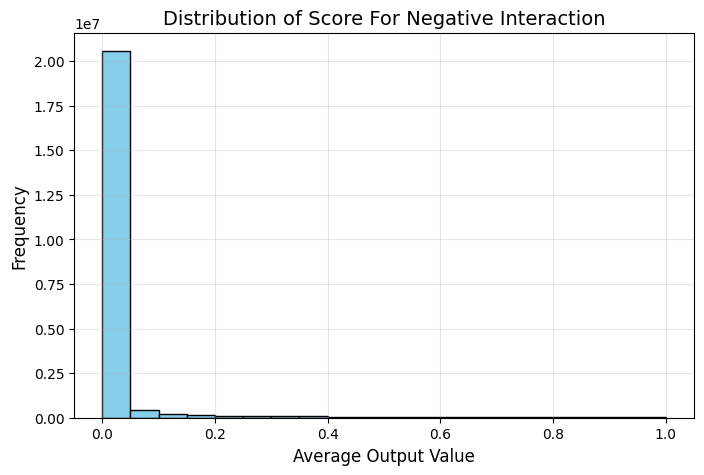

In [52]:
plt.figure(figsize=(8, 5))
plt.hist(df["avg_outputs"], bins=20, color="skyblue", edgecolor="black")
plt.title("Distribution of Score For Negative Interaction", fontsize=14)
plt.xlabel("Average Output Value", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(alpha=0.3)

plt.show()

In [53]:
df["avg_outputs"].unique()

array([7.84234974e-01, 4.60967545e-01, 3.85670998e-01, ...,
       8.13368395e-10, 5.97790084e-10, 9.17067787e-10], shape=(22372160,))

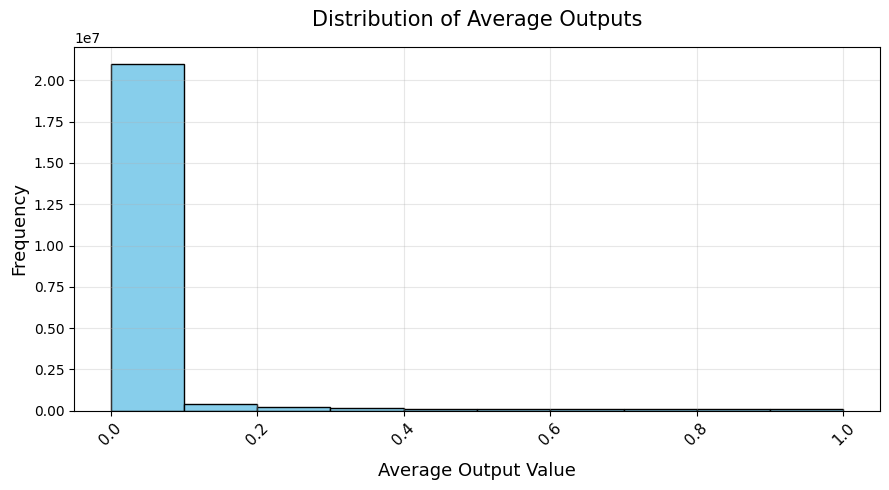

In [5]:
plt.figure(figsize=(9, 5))
plt.hist(df["avg_outputs"], bins=10, color="skyblue", edgecolor="black")

plt.title("Distribution of Average Outputs", fontsize=15, pad=15)
plt.xlabel("Average Output Value", fontsize=13, labelpad=10)
plt.ylabel("Frequency", fontsize=13)

# Make x-axis more readable
plt.xticks(fontsize=11, rotation=45)
plt.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))  # show scientific notation cleanly

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [8]:
value_counts = df["avg_outputs"].value_counts().sort_index()

In [9]:
value_counts

avg_outputs
7.933266e-17    1
1.101268e-16    1
1.270321e-16    1
1.869563e-16    1
2.007804e-16    1
               ..
9.999973e-01    1
9.999976e-01    1
9.999978e-01    1
9.999978e-01    1
9.999993e-01    1
Name: count, Length: 22372160, dtype: int64

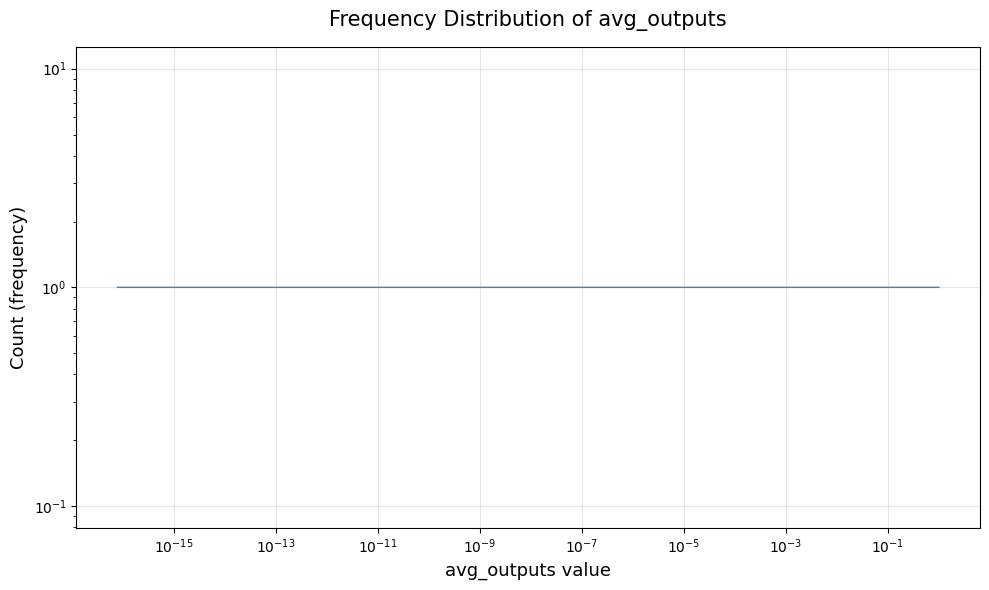

In [7]:
value_counts = df["avg_outputs"].value_counts().sort_index()

# Step 2: Plot (you can sample or bin for large data)
plt.figure(figsize=(10, 6))
plt.plot(value_counts.index, value_counts.values, color='steelblue', linewidth=1)

plt.title("Frequency Distribution of avg_outputs", fontsize=15, pad=15)
plt.xlabel("avg_outputs value", fontsize=13)
plt.ylabel("Count (frequency)", fontsize=13)

plt.xscale("log")  # optional if values span large/small ranges
plt.yscale("log")  # helps visualize long-tail patterns
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


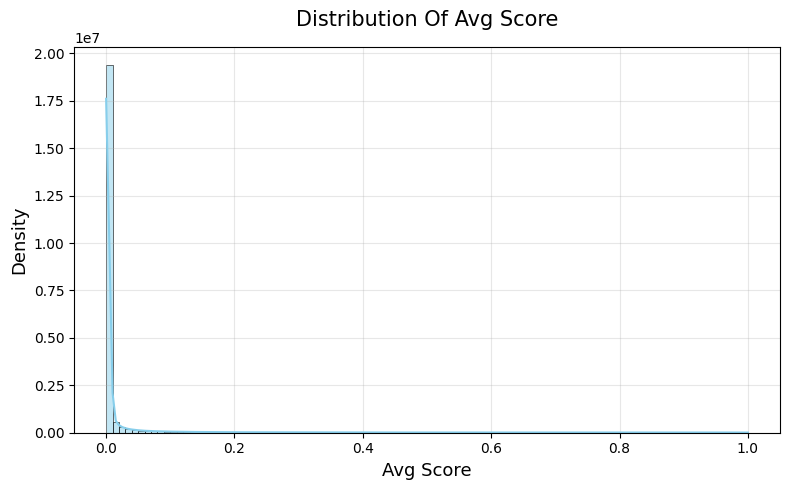

In [48]:
plt.figure(figsize=(8, 5))

# Option 1: Histogram
sns.histplot(df["avg_outputs"], bins=100, kde=True, color="skyblue")

plt.title("Distribution Of Avg Score", fontsize=15, pad=15)
plt.xlabel("Avg Score", fontsize=13)
plt.ylabel("Density", fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


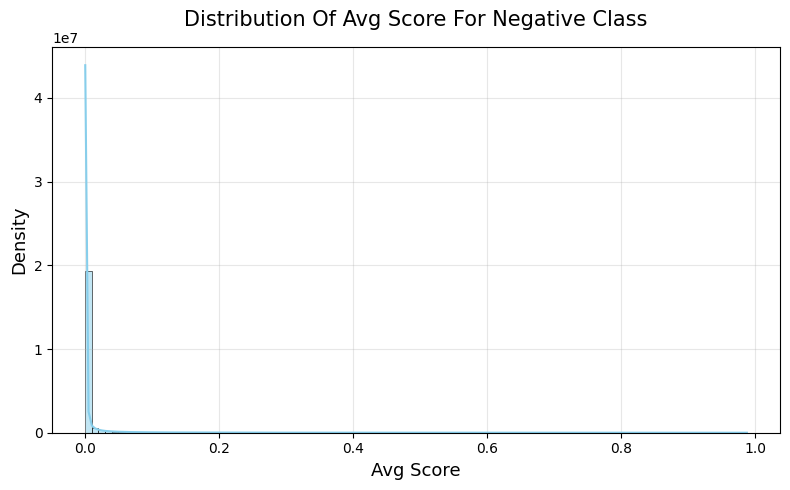

In [49]:
plt.figure(figsize=(8, 5))

# Option 1: Histogram
sns.histplot(df[df["label"]==0]["avg_outputs"], bins=100, kde=True, color="skyblue")

plt.title("Distribution Of Avg Score For Negative Class", fontsize=15, pad=15)
plt.xlabel("Avg Score", fontsize=13)
plt.ylabel("Density", fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

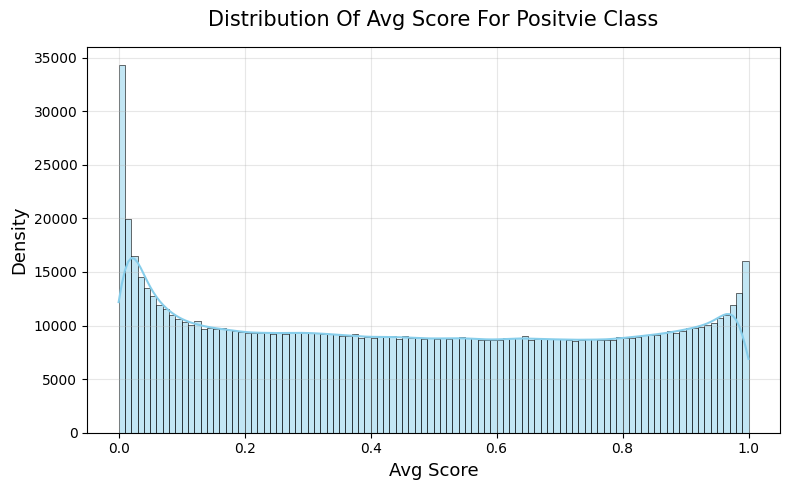

In [54]:
plt.figure(figsize=(8, 5))

# Option 1: Histogram
sns.histplot(df[df["label"]==1]["avg_outputs"], bins=100, kde=True, color="skyblue")

plt.title("Distribution Of Avg Score For Positvie Class", fontsize=15, pad=15)
plt.xlabel("Avg Score", fontsize=13)
plt.ylabel("Density", fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

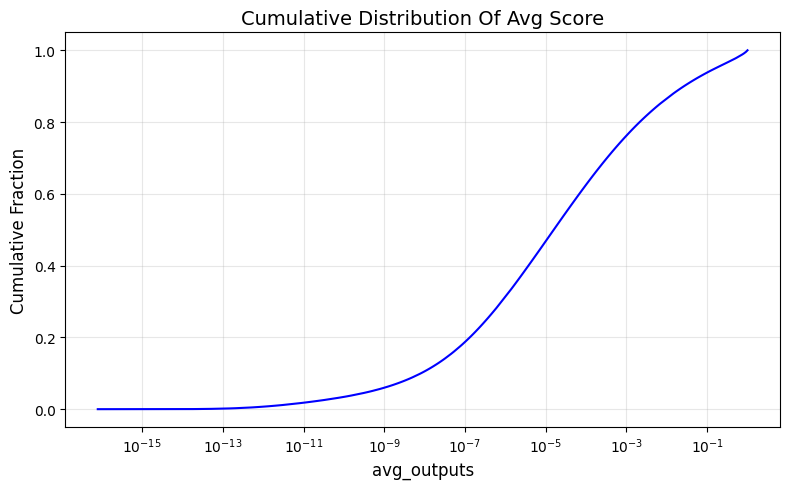

In [56]:
# Sort the values
sorted_vals = np.sort(df["avg_outputs"].values)

# Compute cumulative percentage
cdf = np.arange(len(sorted_vals)) / len(sorted_vals)

plt.figure(figsize=(8, 5))
plt.plot(sorted_vals, cdf, color='blue')
plt.xlabel("avg_outputs", fontsize=12)
plt.ylabel("Cumulative Fraction", fontsize=12)
plt.title("Cumulative Distribution Of Avg Score", fontsize=14)
plt.grid(alpha=0.3)

plt.xscale('log')  # optional, if values are small
plt.tight_layout()
plt.show()


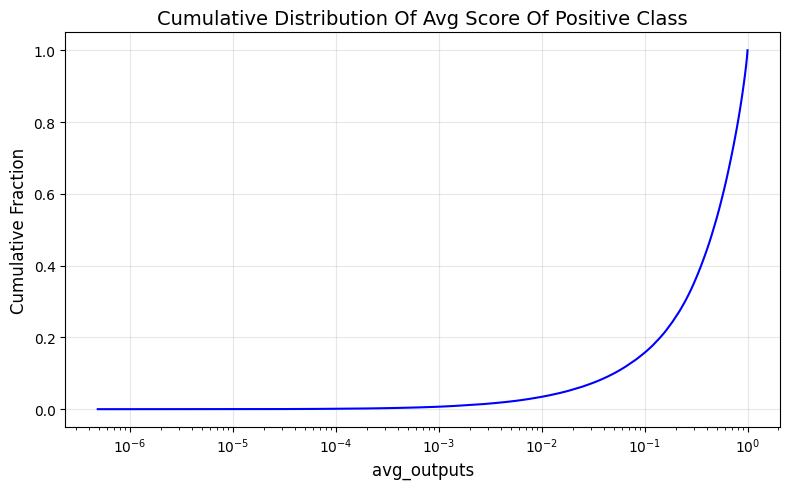

In [57]:
sorted_vals = np.sort(df[df["label"]==1]["avg_outputs"].values)

# Compute cumulative percentage
cdf = np.arange(len(sorted_vals)) / len(sorted_vals)

plt.figure(figsize=(8, 5))
plt.plot(sorted_vals, cdf, color='blue')
plt.xlabel("avg_outputs", fontsize=12)
plt.ylabel("Cumulative Fraction", fontsize=12)
plt.title("Cumulative Distribution Of Avg Score Of Positive Class", fontsize=14)
plt.grid(alpha=0.3)

plt.xscale('log')  # optional, if values are small
plt.tight_layout()
plt.show()

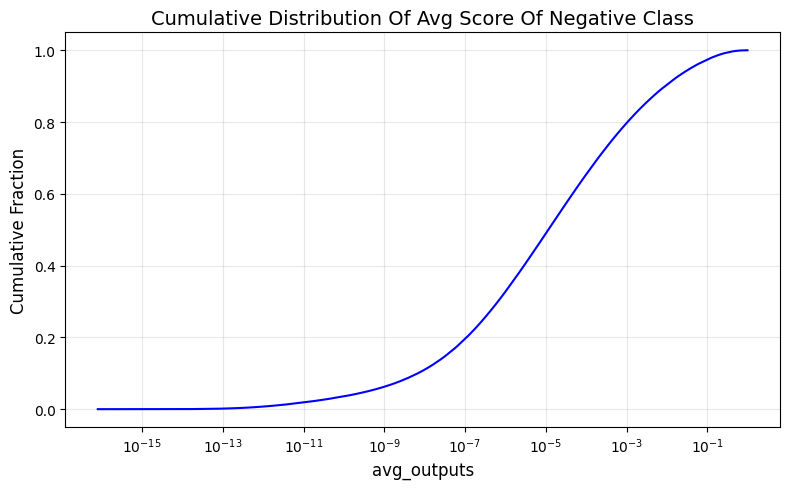

In [59]:
sorted_vals = np.sort(df[df["label"]==0]["avg_outputs"].values)

# Compute cumulative percentage
cdf = np.arange(len(sorted_vals)) / len(sorted_vals)

plt.figure(figsize=(8, 5))
plt.plot(sorted_vals, cdf, color='blue')
plt.xlabel("avg_outputs", fontsize=12)
plt.ylabel("Cumulative Fraction", fontsize=12)
plt.title("Cumulative Distribution Of Avg Score Of Negative Class", fontsize=14)
plt.grid(alpha=0.3)

plt.xscale('log')  # optional, if values are small
plt.tight_layout()
plt.show()

In [13]:
df_sort = df.sort_values(by="avg_outputs", ascending=False)

In [14]:
total_rows = len(df)

In [15]:
total_rows

22372160

In [91]:
row_75 = total_rows*0.75

In [92]:
row_75

16779120.0

In [93]:
22372160 - 16779120

5593040

In [97]:
df_sort[df_sort["label"] == 0]

,user,item,label,output_model3,output_model5,output_model10,avg_outputs
19876753,5366,1075,0,9.901767e-01,9.884929e-01,9.840487e-01,9.875728e-01
14161089,3823,737,0,9.754442e-01,9.983361e-01,9.883977e-01,9.873927e-01
6389471,1725,160,0,9.837795e-01,9.906949e-01,9.850145e-01,9.864963e-01
10282362,2776,126,0,9.813793e-01,9.947536e-01,9.817825e-01,9.859718e-01
13290785,3588,840,0,9.797814e-01,9.877301e-01,9.892504e-01,9.855873e-01
...,...,...,...,...,...,...,...
11930052,3220,3176,0,1.307209e-16,3.753227e-16,9.629750e-17,2.007804e-16
11930026,3220,3154,0,9.914720e-17,3.193206e-16,1.424010e-16,1.869563e-16
5511070,1487,3225,0,1.318920e-16,2.277750e-16,2.142916e-17,1.270321e-16
5511020,1487,3176,0,1.137301e-16,1.914842e-16,2.516627e-17,1.101268e-16


In [101]:
21377991*0.75

16033493.25

In [18]:
new_df = df_sort[df_sort["label"] == 0][:int(21377991*0.40)+1]
all_positive = df_sort[df_sort["label"] == 1]

El2n_40_data = pd.concat([new_df,all_positive], axis=0)
El2n_40_data.reset_index(inplace=True,drop=True)

El2n_40_data.sort_values("user",inplace=True)

El2n_40_data.to_csv("El2n_40_data.csv", index=False)


El2n_40_data

,user,item,label,output_model3,output_model5,output_model10,avg_outputs
8056180,0,853,0,0.000019,0.000125,0.000047,0.000064
8528914,0,2245,0,0.000098,0.000026,0.000016,0.000047
7739254,0,522,0,0.000078,0.000144,0.000014,0.000079
3899879,0,484,0,0.000250,0.000172,0.003960,0.001461
7941117,0,463,0,0.000100,0.000092,0.000014,0.000069
...,...,...,...,...,...,...,...
9357546,6039,950,1,0.173147,0.179171,0.039541,0.130620
586959,6039,1304,0,0.157471,0.060152,0.059694,0.092439
6889851,6039,1147,0,0.000104,0.000064,0.000255,0.000141
5960333,6039,2711,0,0.000353,0.000411,0.000063,0.000276


In [24]:
El2n_40_data.head(5)

,user,item,label,output_model3,output_model5,output_model10,avg_outputs,UserID,ItemID,Timestamp
6760661,0.0,398.0,0,0.000098,0.000301,0.000064,0.000154,NaN,NaN,NaN
7019430,0.0,1039.0,0,0.000153,0.000197,0.000037,0.000129,NaN,NaN,NaN
7788648,0.0,1312.0,0,0.000081,0.000145,0.000002,0.000076,NaN,NaN,NaN
3550981,0.0,1098.0,0,0.000204,0.001898,0.003933,0.002011,NaN,NaN,NaN
3990038,0.0,603.0,0,0.000725,0.003246,0.000072,0.001348,NaN,NaN,NaN


In [23]:
El2n_40_data.dtypes

user              float64
item              float64
label               int64
output_model3     float64
output_model5     float64
output_model10    float64
avg_outputs       float64
UserID            float64
ItemID            float64
Timestamp         float64
dtype: object

In [35]:
all_positive = df_sort[df_sort["label"] == 1]

all_positive.columns = ["UserID","ItemID", "label", "output_model3", "output_model5", "output_model10","avg_outputs"]

d = pd.read_csv("/home/dhruv/Documents/NCF/NCF_Recommendation/NCF_Pytorch/train_data.csv")

all_positive = all_positive.merge(d[['UserID', 'ItemID', 'Timestamp']], on=['UserID', 'ItemID'], how='left')

all_positive

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs,Timestamp
0,190,2777,1,9.999997e-01,9.999989e-01,9.999993e-01,9.999993e-01,977026554
1,732,3308,1,9.999995e-01,9.999990e-01,9.999948e-01,9.999978e-01,975482730
2,579,3225,1,9.999996e-01,9.999945e-01,9.999992e-01,9.999978e-01,975971581
3,1246,3467,1,9.999992e-01,9.999975e-01,9.999960e-01,9.999976e-01,974828904
4,525,2777,1,9.999992e-01,9.999938e-01,9.999989e-01,9.999973e-01,976161325
...,...,...,...,...,...,...,...,...
994164,4509,217,1,3.124745e-06,7.682282e-07,8.332765e-08,1.325434e-06,964988733
994165,5366,189,1,1.532615e-06,4.065221e-07,1.887566e-06,1.275568e-06,960500149
994166,3310,189,1,1.650502e-06,2.967262e-08,3.274863e-07,6.692202e-07,967954970
994167,4509,124,1,7.482980e-07,3.286471e-07,5.932253e-07,5.567235e-07,964988918


In [27]:
all_positive.dtypes

UserID              int64
ItemID              int64
label               int64
output_model3     float64
output_model5     float64
output_model10    float64
avg_outputs       float64
Timestamp           int64
dtype: object

In [32]:
new_df.columns = ["UserID","ItemID", "label", "output_model3", "output_model5", "output_model10","avg_outputs"]
new_df

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs
19876753,5366,1075,0,0.990177,0.988493,0.984049,0.987573
14161089,3823,737,0,0.975444,0.998336,0.988398,0.987393
6389471,1725,160,0,0.983779,0.990695,0.985014,0.986496
10282362,2776,126,0,0.981379,0.994754,0.981782,0.985972
13290785,3588,840,0,0.979781,0.987730,0.989250,0.985587
...,...,...,...,...,...,...,...
8800459,2375,3466,0,0.005333,0.000751,0.002326,0.002803
2015701,544,729,0,0.000148,0.008248,0.000014,0.002803
5110025,1379,2215,0,0.000708,0.003534,0.004168,0.002803
6198088,1673,1311,0,0.000033,0.008184,0.000194,0.002803


In [33]:
new_df

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs
19876753,5366,1075,0,0.990177,0.988493,0.984049,0.987573
14161089,3823,737,0,0.975444,0.998336,0.988398,0.987393
6389471,1725,160,0,0.983779,0.990695,0.985014,0.986496
10282362,2776,126,0,0.981379,0.994754,0.981782,0.985972
13290785,3588,840,0,0.979781,0.987730,0.989250,0.985587
...,...,...,...,...,...,...,...
8800459,2375,3466,0,0.005333,0.000751,0.002326,0.002803
2015701,544,729,0,0.000148,0.008248,0.000014,0.002803
5110025,1379,2215,0,0.000708,0.003534,0.004168,0.002803
6198088,1673,1311,0,0.000033,0.008184,0.000194,0.002803


In [42]:
new_df = df_sort[df_sort["label"] == 0][:int(21377991*0.40)+1]
new_df.columns = ["UserID","ItemID", "label", "output_model3", "output_model5", "output_model10","avg_outputs"]
El2n_40_data = pd.concat([new_df,all_positive], axis=0)

El2n_40_data.reset_index(inplace=True,drop=True)

El2n_40_data.sort_values("UserID",inplace=True)
El2n_40_data.fillna(0, inplace=True)
El2n_40_data.to_csv("El2n_40_data.csv", index=False)




new_df = df_sort[df_sort["label"] == 0][:int(21377991*0.30)+1]
new_df.columns = ["UserID","ItemID", "label", "output_model3", "output_model5", "output_model10","avg_outputs"]
El2n_30_data = pd.concat([new_df,all_positive], axis=0)
El2n_30_data.reset_index(inplace=True,drop=True)

El2n_30_data.sort_values("UserID",inplace=True)
El2n_30_data.fillna(0, inplace=True)
El2n_30_data.to_csv("El2n_30_data.csv", index=False)




new_df = df_sort[df_sort["label"] == 0][:int(21377991*0.25)+1]
new_df.columns = ["UserID","ItemID", "label", "output_model3", "output_model5", "output_model10","avg_outputs"]
El2n_25_data = pd.concat([new_df,all_positive], axis=0)
El2n_25_data.reset_index(inplace=True,drop=True)

El2n_25_data.sort_values("UserID",inplace=True)
El2n_25_data.fillna(0, inplace=True)
El2n_25_data.to_csv("El2n_25_data.csv", index=False)




new_df = df_sort[df_sort["label"] == 0][:int(21377991*0.20)+1]
new_df.columns = ["UserID","ItemID", "label", "output_model3", "output_model5", "output_model10","avg_outputs"]
El2n_20_data = pd.concat([new_df,all_positive], axis=0)
El2n_20_data.reset_index(inplace=True,drop=True)

El2n_20_data.sort_values("UserID",inplace=True)
El2n_20_data.fillna(0, inplace=True)
El2n_20_data.to_csv("El2n_20_data.csv", index=False)





new_df = df_sort[df_sort["label"] == 0][:int(21377991*0.15)+1]
new_df.columns = ["UserID","ItemID", "label", "output_model3", "output_model5", "output_model10","avg_outputs"]
El2n_15_data = pd.concat([new_df,all_positive], axis=0)
El2n_15_data.reset_index(inplace=True,drop=True)

El2n_15_data.sort_values("UserID",inplace=True)
El2n_15_data.fillna(0, inplace=True)

El2n_15_data.to_csv("El2n_15_data.csv", index=False)

In [43]:
El2n_15_data

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs,Timestamp
2625725,0,315,0,0.001301,0.013520,0.000502,0.005108,0.0
1693230,0,156,0,0.002779,0.006493,0.037398,0.015557,0.0
334480,0,127,0,0.033442,0.239981,0.219901,0.164441,0.0
2737747,0,210,0,0.001497,0.004573,0.007525,0.004532,0.0
3587980,0,45,1,0.872941,0.382069,0.535914,0.596975,978301777.0
...,...,...,...,...,...,...,...,...
4074072,6039,23,1,0.055116,0.069489,0.094330,0.072978,956704219.0
3801435,6039,186,1,0.345913,0.437959,0.284622,0.356165,956715942.0
3801516,6039,1605,1,0.362248,0.281977,0.423930,0.356051,957717017.0
682622,6039,92,0,0.105169,0.078990,0.045099,0.076419,0.0


In [103]:
new_df = df_sort[df_sort["label"] == 0][:16033493+1]

In [104]:
new_df

,user,item,label,output_model3,output_model5,output_model10,avg_outputs
19876753,5366,1075,0,9.901767e-01,9.884929e-01,9.840487e-01,9.875728e-01
14161089,3823,737,0,9.754442e-01,9.983361e-01,9.883977e-01,9.873927e-01
6389471,1725,160,0,9.837795e-01,9.906949e-01,9.850145e-01,9.864963e-01
10282362,2776,126,0,9.813793e-01,9.947536e-01,9.817825e-01,9.859718e-01
13290785,3588,840,0,9.797814e-01,9.877301e-01,9.892504e-01,9.855873e-01
...,...,...,...,...,...,...,...
13144814,3548,3025,0,8.084938e-07,1.368156e-08,2.096231e-08,2.810459e-07
14859310,4011,2578,0,7.060136e-07,4.338515e-08,9.373869e-08,2.810458e-07
1395649,376,2944,0,1.322120e-07,6.282704e-07,8.265497e-08,2.810458e-07
21635374,5841,339,0,2.255188e-07,4.718703e-07,1.457459e-07,2.810450e-07


In [98]:
21377991*0.75

16033493.25

In [122]:
all_positive = df_sort[df_sort["label"] == 1]
all_positive

,user,item,label,output_model3,output_model5,output_model10,avg_outputs
706533,190,2777,1,9.999997e-01,9.999989e-01,9.999993e-01,9.999993e-01
2714630,732,3308,1,9.999995e-01,9.999990e-01,9.999948e-01,9.999978e-01
2147838,579,3225,1,9.999996e-01,9.999945e-01,9.999992e-01,9.999978e-01
4618644,1246,3467,1,9.999992e-01,9.999975e-01,9.999960e-01,9.999976e-01
1947373,525,2777,1,9.999992e-01,9.999938e-01,9.999989e-01,9.999973e-01
...,...,...,...,...,...,...,...
16701544,4509,217,1,3.124745e-06,7.682282e-07,8.332765e-08,1.325434e-06
19875858,5366,189,1,1.532615e-06,4.065221e-07,1.887566e-06,1.275568e-06
12260434,3310,189,1,1.650502e-06,2.967262e-08,3.274863e-07,6.692202e-07
16701483,4509,124,1,7.482980e-07,3.286471e-07,5.932253e-07,5.567235e-07


In [123]:
994169*0.75

745626.75

In [125]:
all_positive = all_positive[:745626]
all_positive

,user,item,label,output_model3,output_model5,output_model10,avg_outputs
706533,190,2777,1,1.000000,0.999999,0.999999,0.999999
2714630,732,3308,1,1.000000,0.999999,0.999995,0.999998
2147838,579,3225,1,1.000000,0.999994,0.999999,0.999998
4618644,1246,3467,1,0.999999,0.999998,0.999996,0.999998
1947373,525,2777,1,0.999999,0.999994,0.999999,0.999997
...,...,...,...,...,...,...,...
8101359,2187,642,1,0.422617,0.040645,0.117355,0.193539
11776329,3179,1376,1,0.130756,0.075348,0.374513,0.193539
18557622,5010,573,1,0.480301,0.038426,0.061889,0.193539
15331736,4139,904,1,0.102105,0.374435,0.104072,0.193537


In [126]:
all_positive.sort_values("user",inplace=True)

/tmp/ipykernel_82436/1630673808.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_positive.sort_values("user",inplace=True)


In [127]:
all_positive.reset_index(inplace=True, drop=True)

In [128]:
all_positive

,user,item,label,output_model3,output_model5,output_model10,avg_outputs
0,0,30,1,0.950120,0.759607,0.680503,0.796743
1,0,37,1,0.920445,0.440455,0.562293,0.641064
2,0,19,1,0.909427,0.595991,0.807545,0.770988
3,0,4,1,0.705434,0.108107,0.343472,0.385671
4,0,31,1,0.976514,0.970144,0.949974,0.965544
...,...,...,...,...,...,...,...
745621,6039,1126,1,0.559346,0.376879,0.641982,0.526069
745622,6039,1235,1,0.338418,0.223428,0.195764,0.252536
745623,6039,461,1,0.725876,0.901293,0.909166,0.845445
745624,6039,2517,1,0.784274,0.732244,0.676122,0.730880


In [130]:
all_positive.columns = ["UserID","ItemID", "label", "output_model3", "output_model5", "output_model10","avg_outputs"]
all_positive

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs
0,0,30,1,0.950120,0.759607,0.680503,0.796743
1,0,37,1,0.920445,0.440455,0.562293,0.641064
2,0,19,1,0.909427,0.595991,0.807545,0.770988
3,0,4,1,0.705434,0.108107,0.343472,0.385671
4,0,31,1,0.976514,0.970144,0.949974,0.965544
...,...,...,...,...,...,...,...
745621,6039,1126,1,0.559346,0.376879,0.641982,0.526069
745622,6039,1235,1,0.338418,0.223428,0.195764,0.252536
745623,6039,461,1,0.725876,0.901293,0.909166,0.845445
745624,6039,2517,1,0.784274,0.732244,0.676122,0.730880


In [132]:
d = pd.read_csv("/home/dhruv/Documents/NCF/NCF_Recommendation/NCF_Pytorch/train_data.csv")
d

,UserID,ItemID,Rating,Timestamp
0,0,32,4,978824330
1,0,34,4,978824330
2,0,4,5,978824291
3,0,35,4,978824291
4,0,30,4,978824291
...,...,...,...,...
994164,6039,1092,5,956703977
994165,6039,41,4,956703977
994166,6039,128,5,956703954
994167,6039,323,4,956703954


In [136]:
all_positive = all_positive.merge(d[['UserID', 'ItemID', 'Timestamp']], on=['UserID', 'ItemID'], how='left')


In [137]:
all_positive

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs,Timestamp
0,0,30,1,0.950120,0.759607,0.680503,0.796743,978824291
1,0,37,1,0.920445,0.440455,0.562293,0.641064,978300055
2,0,19,1,0.909427,0.595991,0.807545,0.770988,978302039
3,0,4,1,0.705434,0.108107,0.343472,0.385671,978824291
4,0,31,1,0.976514,0.970144,0.949974,0.965544,978300019
...,...,...,...,...,...,...,...,...
745621,6039,1126,1,0.559346,0.376879,0.641982,0.526069,957717423
745622,6039,1235,1,0.338418,0.223428,0.195764,0.252536,956715288
745623,6039,461,1,0.725876,0.901293,0.909166,0.845445,997454486
745624,6039,2517,1,0.784274,0.732244,0.676122,0.730880,956704056


In [138]:
all_positive.to_csv("El2n_positive.csv", index=False)


In [107]:
El2n_75_data = pd.concat([new_df,all_positive], axis=0)
El2n_75_data

,user,item,label,output_model3,output_model5,output_model10,avg_outputs
19876753,5366,1075,0,9.901767e-01,9.884929e-01,9.840487e-01,9.875728e-01
14161089,3823,737,0,9.754442e-01,9.983361e-01,9.883977e-01,9.873927e-01
6389471,1725,160,0,9.837795e-01,9.906949e-01,9.850145e-01,9.864963e-01
10282362,2776,126,0,9.813793e-01,9.947536e-01,9.817825e-01,9.859718e-01
13290785,3588,840,0,9.797814e-01,9.877301e-01,9.892504e-01,9.855873e-01
...,...,...,...,...,...,...,...
16701544,4509,217,1,3.124745e-06,7.682282e-07,8.332765e-08,1.325434e-06
19875858,5366,189,1,1.532615e-06,4.065221e-07,1.887566e-06,1.275568e-06
12260434,3310,189,1,1.650502e-06,2.967262e-08,3.274863e-07,6.692202e-07
16701483,4509,124,1,7.482980e-07,3.286471e-07,5.932253e-07,5.567235e-07


In [110]:
El2n_75_data.reset_index(inplace=True,drop=True)

In [113]:
El2n_75_data.drop(["index"], axis=1, inplace=True)

In [114]:
El2n_75_data

,user,item,label,output_model3,output_model5,output_model10,avg_outputs
0,5366,1075,0,9.901767e-01,9.884929e-01,9.840487e-01,9.875728e-01
1,3823,737,0,9.754442e-01,9.983361e-01,9.883977e-01,9.873927e-01
2,1725,160,0,9.837795e-01,9.906949e-01,9.850145e-01,9.864963e-01
3,2776,126,0,9.813793e-01,9.947536e-01,9.817825e-01,9.859718e-01
4,3588,840,0,9.797814e-01,9.877301e-01,9.892504e-01,9.855873e-01
...,...,...,...,...,...,...,...
17027658,4509,217,1,3.124745e-06,7.682282e-07,8.332765e-08,1.325434e-06
17027659,5366,189,1,1.532615e-06,4.065221e-07,1.887566e-06,1.275568e-06
17027660,3310,189,1,1.650502e-06,2.967262e-08,3.274863e-07,6.692202e-07
17027661,4509,124,1,7.482980e-07,3.286471e-07,5.932253e-07,5.567235e-07


In [116]:
El2n_75_data.sort_values("user",inplace=True)

In [117]:
El2n_75_data.to_csv("El2n_75_data.csv", index=False)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn

In [2]:
df = pd.read_csv("/home/dhruv/Documents/NCF/NCF_Recommendation/NCF_Pytorch/Custom_User_centric_batch/all_user_item_data_with_result.csv")
df.head()

,user,item,label,output_model3,output_model5,output_model10,avg_outputs
0,0,32,1,0.942623,0.696994,0.713088,0.784235
1,0,34,1,0.872383,0.383507,0.127013,0.460968
2,0,4,1,0.705434,0.108107,0.343472,0.385671
3,0,35,1,0.962766,0.721432,0.633812,0.772670
4,0,30,1,0.950120,0.759607,0.680503,0.796743


In [3]:
df["label"].unique()

array([1, 0])

In [4]:
df["label"].value_counts()

label
0    21377991
1      994169
Name: count, dtype: int64

In [5]:
df.head(25)

,user,item,label,output_model3,output_model5,output_model10,avg_outputs
0,0,32,1,0.942623,0.696994,0.713088,0.784235
1,0,34,1,0.872383,0.383507,0.127013,0.460968
2,0,4,1,0.705434,0.108107,0.343472,0.385671
3,0,35,1,0.962766,0.721432,0.633812,0.772670
4,0,30,1,0.950120,0.759607,0.680503,0.796743
5,0,29,1,0.901382,0.632957,0.773328,0.769222
6,0,33,1,0.752740,0.071526,0.044561,0.289609
7,0,40,1,0.649944,0.067455,0.045047,0.254148
8,0,10,1,0.824309,0.064824,0.034647,0.307927
9,0,16,1,0.831457,0.345810,0.061418,0.412895


In [6]:
df.tail(25)

,user,item,label,output_model3,output_model5,output_model10,avg_outputs
22372135,6039,3681,0,1.250981e-08,1.988580e-07,4.975978e-08,8.704253e-08
22372136,6039,3682,0,1.288638e-08,4.420637e-07,6.102324e-08,1.719911e-07
22372137,6039,3683,0,7.440594e-09,8.947243e-08,5.232853e-08,4.974718e-08
22372138,6039,3684,0,1.338627e-08,1.891548e-07,5.919168e-08,8.724426e-08
22372139,6039,3685,0,5.310955e-09,3.237061e-08,1.121385e-08,1.629847e-08
22372140,6039,3686,0,3.310560e-09,2.846008e-08,2.365767e-08,1.847610e-08
22372141,6039,3687,0,4.566786e-09,3.854294e-08,1.627522e-08,1.979498e-08
22372142,6039,3688,0,7.250718e-09,1.531156e-07,1.122275e-07,9.086461e-08
22372143,6039,3689,0,2.006192e-08,3.120601e-07,8.875587e-08,1.402926e-07
22372144,6039,3690,0,1.669026e-08,1.595688e-07,3.487475e-08,7.037792e-08


In [7]:
positive_df = df[df["label"]==1]
positive_df

,user,item,label,output_model3,output_model5,output_model10,avg_outputs
0,0,32,1,0.942623,0.696994,0.713088,0.784235
1,0,34,1,0.872383,0.383507,0.127013,0.460968
2,0,4,1,0.705434,0.108107,0.343472,0.385671
3,0,35,1,0.962766,0.721432,0.633812,0.772670
4,0,30,1,0.950120,0.759607,0.680503,0.796743
...,...,...,...,...,...,...,...
22371357,6039,2907,1,0.973753,0.960745,0.972769,0.969089
22371406,6039,2955,1,0.968587,0.966734,0.956657,0.963993
22371490,6039,3042,1,0.960018,0.953148,0.955932,0.956366
22371498,6039,3046,1,0.977398,0.954056,0.951146,0.960867


In [8]:
positive_df.sort_values("avg_outputs", ascending=False)

,user,item,label,output_model3,output_model5,output_model10,avg_outputs
706533,190,2777,1,9.999997e-01,9.999989e-01,9.999993e-01,9.999993e-01
2714630,732,3308,1,9.999995e-01,9.999990e-01,9.999948e-01,9.999978e-01
2147838,579,3225,1,9.999996e-01,9.999945e-01,9.999992e-01,9.999978e-01
4618644,1246,3467,1,9.999992e-01,9.999975e-01,9.999960e-01,9.999976e-01
1947373,525,2777,1,9.999992e-01,9.999938e-01,9.999989e-01,9.999973e-01
...,...,...,...,...,...,...,...
16701544,4509,217,1,3.124745e-06,7.682282e-07,8.332765e-08,1.325434e-06
19875858,5366,189,1,1.532615e-06,4.065221e-07,1.887566e-06,1.275568e-06
12260434,3310,189,1,1.650502e-06,2.967262e-08,3.274863e-07,6.692202e-07
16701483,4509,124,1,7.482980e-07,3.286471e-07,5.932253e-07,5.567235e-07


In [9]:
994169*0.40

397667.60000000003

In [10]:
min(positive_df["user"]), max(positive_df["user"])

(0, 6039)

In [11]:
positive_df.columns = ["UserID","ItemID", "label", "output_model3", "output_model5", "output_model10","avg_outputs"]
positive_df

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs
0,0,32,1,0.942623,0.696994,0.713088,0.784235
1,0,34,1,0.872383,0.383507,0.127013,0.460968
2,0,4,1,0.705434,0.108107,0.343472,0.385671
3,0,35,1,0.962766,0.721432,0.633812,0.772670
4,0,30,1,0.950120,0.759607,0.680503,0.796743
...,...,...,...,...,...,...,...
22371357,6039,2907,1,0.973753,0.960745,0.972769,0.969089
22371406,6039,2955,1,0.968587,0.966734,0.956657,0.963993
22371490,6039,3042,1,0.960018,0.953148,0.955932,0.956366
22371498,6039,3046,1,0.977398,0.954056,0.951146,0.960867


In [12]:

d = pd.read_csv("/home/dhruv/Documents/NCF/NCF_Recommendation/NCF_Pytorch/train_data.csv")

all_positive = positive_df.merge(d[['UserID', 'ItemID', 'Timestamp']], on=['UserID', 'ItemID'], how='left')

all_positive

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs,Timestamp
0,0,32,1,0.942623,0.696994,0.713088,0.784235,978824330
1,0,34,1,0.872383,0.383507,0.127013,0.460968,978824330
2,0,4,1,0.705434,0.108107,0.343472,0.385671,978824291
3,0,35,1,0.962766,0.721432,0.633812,0.772670,978824291
4,0,30,1,0.950120,0.759607,0.680503,0.796743,978824291
...,...,...,...,...,...,...,...,...
994164,6039,2907,1,0.973753,0.960745,0.972769,0.969089,960971893
994165,6039,2955,1,0.968587,0.966734,0.956657,0.963993,956716438
994166,6039,3042,1,0.960018,0.953148,0.955932,0.956366,956704305
994167,6039,3046,1,0.977398,0.954056,0.951146,0.960867,960971992


In [13]:
positive_df_40 = all_positive.sort_values("avg_outputs", ascending=False)[:int(994169*0.40)]
positive_df_40

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs,Timestamp
26714,190,2777,1,1.000000,0.999999,0.999999,0.999999,977026554
112360,732,3308,1,1.000000,0.999999,0.999995,0.999998,975482730
87546,579,3225,1,1.000000,0.999994,0.999999,0.999998,975971581
202190,1246,3467,1,0.999999,0.999998,0.999996,0.999998,974828904
77636,525,2777,1,0.999999,0.999994,0.999999,0.999997,976161325
...,...,...,...,...,...,...,...,...
456884,2832,219,1,0.961490,0.765481,0.007224,0.578065,972586233
197421,1219,825,1,0.286658,0.922770,0.524765,0.578064,974927002
40225,271,1089,1,0.516013,0.584904,0.633275,0.578064,976697219
974268,5914,641,1,0.246238,0.798688,0.689263,0.578063,957333189


In [16]:
min(positive_df_40["UserID"]), max(positive_df_40["UserID"])

(0, 6039)

In [17]:
not_n_list = []


for i in range(6040):
    if i not in positive_df_40["UserID"].to_list():
        not_n_list.append(i)
        
        
not_n_list

[]

In [18]:
positive_df_40["UserID"].nunique()

6040

In [19]:
len(not_n_list)

0

In [20]:
positive_df_40

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs,Timestamp
26714,190,2777,1,1.000000,0.999999,0.999999,0.999999,977026554
112360,732,3308,1,1.000000,0.999999,0.999995,0.999998,975482730
87546,579,3225,1,1.000000,0.999994,0.999999,0.999998,975971581
202190,1246,3467,1,0.999999,0.999998,0.999996,0.999998,974828904
77636,525,2777,1,0.999999,0.999994,0.999999,0.999997,976161325
...,...,...,...,...,...,...,...,...
456884,2832,219,1,0.961490,0.765481,0.007224,0.578065,972586233
197421,1219,825,1,0.286658,0.922770,0.524765,0.578064,974927002
40225,271,1089,1,0.516013,0.584904,0.633275,0.578064,976697219
974268,5914,641,1,0.246238,0.798688,0.689263,0.578063,957333189


In [22]:
df.head(5)

,user,item,label,output_model3,output_model5,output_model10,avg_outputs
0,0,32,1,0.942623,0.696994,0.713088,0.784235
1,0,34,1,0.872383,0.383507,0.127013,0.460968
2,0,4,1,0.705434,0.108107,0.343472,0.385671
3,0,35,1,0.962766,0.721432,0.633812,0.772670
4,0,30,1,0.950120,0.759607,0.680503,0.796743


In [24]:
df_neg = df[df["label"] == 0]
df_neg

,user,item,label,output_model3,output_model5,output_model10,avg_outputs
52,0,86,0,4.643744e-05,8.466645e-05,1.475721e-05,4.862036e-05
53,0,66,0,2.157320e-06,3.136450e-08,2.733794e-08,7.386742e-07
54,0,72,0,8.955023e-06,1.285221e-06,8.289529e-06,6.176591e-06
55,0,130,0,3.625470e-06,2.406843e-07,2.611252e-06,2.159135e-06
56,0,73,0,7.976156e-06,4.337289e-07,1.004713e-06,3.138199e-06
...,...,...,...,...,...,...,...
22372155,6039,3701,0,4.702127e-10,5.559903e-09,1.563683e-08,7.222314e-09
22372156,6039,3702,0,3.691942e-10,2.151343e-09,4.854376e-09,2.458304e-09
22372157,6039,3703,0,1.991666e-10,7.237424e-10,1.517196e-09,8.133684e-10
22372158,6039,3704,0,7.314584e-11,5.109438e-10,1.209281e-09,5.977901e-10


In [27]:
df_neg.columns = ["UserID","ItemID", "label", "output_model3", "output_model5", "output_model10","avg_outputs"]
El2n_positive_40_data = pd.concat([df_neg,positive_df_40], axis=0)

In [28]:
El2n_positive_40_data

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs,Timestamp
52,0,86,0,0.000046,8.466645e-05,1.475721e-05,4.862036e-05,NaN
53,0,66,0,0.000002,3.136450e-08,2.733794e-08,7.386742e-07,NaN
54,0,72,0,0.000009,1.285221e-06,8.289529e-06,6.176591e-06,NaN
55,0,130,0,0.000004,2.406843e-07,2.611252e-06,2.159135e-06,NaN
56,0,73,0,0.000008,4.337289e-07,1.004713e-06,3.138199e-06,NaN
...,...,...,...,...,...,...,...,...
456884,2832,219,1,0.961490,7.654810e-01,7.224024e-03,5.780649e-01,972586233.0
197421,1219,825,1,0.286658,9.227696e-01,5.247651e-01,5.780643e-01,974927002.0
40225,271,1089,1,0.516013,5.849044e-01,6.332753e-01,5.780643e-01,976697219.0
974268,5914,641,1,0.246238,7.986881e-01,6.892628e-01,5.780628e-01,957333189.0


In [29]:
df_neg = df[df["label"] == 0]
df_neg.columns = ["UserID","ItemID", "label", "output_model3", "output_model5", "output_model10","avg_outputs"]
El2n_positive_40_data = pd.concat([df_neg,positive_df_40], axis=0)

El2n_positive_40_data.reset_index(inplace=True,drop=True)

El2n_positive_40_data.sort_values("UserID",inplace=True)
El2n_positive_40_data.fillna(0, inplace=True)
El2n_positive_40_data.to_csv("El2n_positive_40_data.csv", index=False)

In [44]:
positive_df_20 = all_positive.sort_values("avg_outputs", ascending=False)[:int(994169*0.20)]

print(positive_df_20["UserID"].nunique())

6040


In [45]:
positive_df_30 = all_positive.sort_values("avg_outputs", ascending=False)[:int(994169*0.30)]

print(positive_df_30["UserID"].nunique())

6040


In [46]:
positive_df_15 = all_positive.sort_values("avg_outputs", ascending=False)[:int(994169*0.15)]

print(positive_df_15["UserID"].nunique())

6040


In [33]:
positive_df_15["UserID"].value_counts()

UserID
4501    138
4226    136
1752    133
4317    132
1217    130
       ... 
2523      1
2538      1
2552      1
2387      1
2757      1
Name: count, Length: 6040, dtype: int64

In [34]:
positive_df_15["UserID"].value_counts().to_dict()

{4501: 138,
 4226: 136,
 1752: 133,
 4317: 132,
 1217: 130,
 2101: 124,
 4530: 121,
 52: 120,
 4595: 118,
 1146: 115,
 3867: 110,
 4355: 110,
 3557: 109,
 194: 103,
 5095: 103,
 4495: 101,
 3745: 100,
 4665: 100,
 1241: 100,
 4799: 99,
 1353: 95,
 3930: 95,
 4259: 93,
 5055: 93,
 1265: 92,
 4572: 92,
 4241: 92,
 4212: 91,
 3013: 91,
 61: 91,
 5568: 90,
 5850: 90,
 3527: 89,
 4482: 87,
 2021: 86,
 168: 86,
 1267: 86,
 2040: 86,
 4359: 85,
 5160: 85,
 135: 85,
 2030: 85,
 1508: 84,
 4008: 84,
 165: 84,
 1746: 84,
 3410: 84,
 3973: 84,
 5839: 83,
 342: 83,
 3829: 83,
 1927: 83,
 5567: 83,
 3945: 82,
 4052: 82,
 1488: 82,
 4661: 81,
 4293: 81,
 1766: 81,
 1968: 81,
 4737: 81,
 3893: 80,
 1469: 80,
 1698: 80,
 3535: 79,
 4643: 79,
 3926: 79,
 1700: 79,
 3863: 78,
 292: 78,
 4015: 78,
 3992: 78,
 1747: 77,
 2041: 77,
 5084: 76,
 4679: 76,
 1164: 76,
 4413: 76,
 2144: 76,
 4178: 75,
 4242: 75,
 4625: 75,
 3414: 75,
 1338: 75,
 4327: 74,
 1316: 74,
 1270: 74,
 1151: 74,
 2263: 74,
 766: 73,
 4

In [47]:
user_having_less_50 = []


for key, value in positive_df_15["UserID"].value_counts().to_dict().items():
    if value < 50 :
        user_having_less_50.append(key)

In [48]:
user_having_less_50

[1749,
 1296,
 2015,
 5544,
 3686,
 5666,
 4353,
 694,
 4459,
 1136,
 3864,
 186,
 1803,
 2239,
 3313,
 4939,
 4298,
 710,
 4182,
 1925,
 1763,
 3597,
 2749,
 4097,
 5377,
 1290,
 1701,
 3690,
 3639,
 4822,
 1154,
 2640,
 1483,
 3823,
 223,
 1141,
 3300,
 3964,
 3504,
 3421,
 5058,
 236,
 1745,
 4951,
 5280,
 91,
 3831,
 2858,
 4,
 1778,
 4343,
 4590,
 3486,
 500,
 1688,
 3891,
 299,
 714,
 4057,
 266,
 5873,
 4794,
 1631,
 3772,
 628,
 5271,
 2075,
 2142,
 3660,
 2123,
 5955,
 5570,
 2281,
 2105,
 4807,
 5518,
 2014,
 515,
 1959,
 3832,
 3113,
 2503,
 4728,
 3359,
 126,
 4476,
 697,
 2017,
 4605,
 4118,
 807,
 1118,
 5962,
 775,
 5697,
 837,
 2049,
 3369,
 5512,
 2063,
 5022,
 5222,
 1754,
 4439,
 4424,
 3762,
 3054,
 1065,
 5975,
 213,
 4823,
 4555,
 3843,
 5209,
 1061,
 5535,
 4192,
 1027,
 272,
 4071,
 3657,
 2918,
 5293,
 2071,
 334,
 2996,
 475,
 5916,
 3413,
 3638,
 411,
 57,
 5735,
 6001,
 3671,
 1183,
 1654,
 587,
 910,
 2035,
 2989,
 4633,
 669,
 301,
 1550,
 5751,
 1945,
 50

In [49]:
len(user_having_less_50)

5588

In [50]:
user_having_less_50 = []


for key, value in positive_df_20["UserID"].value_counts().to_dict().items():
    if value < 50 :
        user_having_less_50.append(key)
        
        
len(user_having_less_50)

4936

In [51]:
user_having_less_50 = []


for key, value in positive_df_30["UserID"].value_counts().to_dict().items():
    if value < 50 :
        user_having_less_50.append(key)
        
        
len(user_having_less_50)

3634

In [52]:
user_having_less_50 = []


for key, value in positive_df_30["UserID"].value_counts().to_dict().items():
    if value < 50 :
        user_having_less_50.append(key)
        
        
len(user_having_less_50)

3634

In [57]:
user_having_less_50 = []

user_having_less_10 = []

for key, value in positive_df_40["UserID"].value_counts().to_dict().items():
    if value < 50 :
        user_having_less_50.append(key)
    if value < 10 : 
        user_having_less_10.append(key)
        
        
print(len(user_having_less_50))
print(len(user_having_less_10))

2831
18


In [54]:
positive_df_75 = all_positive.sort_values("avg_outputs", ascending=False)[:int(994169*0.75)]

print(positive_df_75["UserID"].nunique())

6040


In [56]:
user_having_less_50 = []

user_having_less_10 = []

for key, value in positive_df_75["UserID"].value_counts().to_dict().items():
    if value < 50 :
        user_having_less_50.append(key)
    if value < 10 : 
        user_having_less_10.append(key)
        
        
print(len(user_having_less_50))
print(len(user_having_less_10))

1894
0


In [58]:
all_positive

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs,Timestamp
0,0,32,1,0.942623,0.696994,0.713088,0.784235,978824330
1,0,34,1,0.872383,0.383507,0.127013,0.460968,978824330
2,0,4,1,0.705434,0.108107,0.343472,0.385671,978824291
3,0,35,1,0.962766,0.721432,0.633812,0.772670,978824291
4,0,30,1,0.950120,0.759607,0.680503,0.796743,978824291
...,...,...,...,...,...,...,...,...
994164,6039,2907,1,0.973753,0.960745,0.972769,0.969089,960971893
994165,6039,2955,1,0.968587,0.966734,0.956657,0.963993,956716438
994166,6039,3042,1,0.960018,0.953148,0.955932,0.956366,956704305
994167,6039,3046,1,0.977398,0.954056,0.951146,0.960867,960971992


In [59]:
user_having_less_50 = []

user_having_less_10 = []

for key, value in all_positive["UserID"].value_counts().to_dict().items():
    if value < 50 :
        user_having_less_50.append(key)
    if value < 10 : 
        user_having_less_10.append(key)
        
        
print(len(user_having_less_50))
print(len(user_having_less_10))

1793
0


In [60]:
df_neg = df[df["label"] == 0]
df_neg.columns = ["UserID","ItemID", "label", "output_model3", "output_model5", "output_model10","avg_outputs"]
El2n_positive_75_data = pd.concat([df_neg,positive_df_75], axis=0)

El2n_positive_75_data.reset_index(inplace=True,drop=True)

El2n_positive_75_data.sort_values("UserID",inplace=True)
El2n_positive_75_data.fillna(0, inplace=True)
El2n_positive_75_data.to_csv("El2n_positive_75_data.csv", index=False)

In [61]:
positive_df_75

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs,Timestamp
26714,190,2777,1,1.000000,0.999999,0.999999,0.999999,977026554
112360,732,3308,1,1.000000,0.999999,0.999995,0.999998,975482730
87546,579,3225,1,1.000000,0.999994,0.999999,0.999998,975971581
202190,1246,3467,1,0.999999,0.999998,0.999996,0.999998,974828904
77636,525,2777,1,0.999999,0.999994,0.999999,0.999997,976161325
...,...,...,...,...,...,...,...,...
373395,2187,642,1,0.422617,0.040645,0.117355,0.193539,974607751
511844,3179,1376,1,0.130756,0.075348,0.374513,0.193539,968801403
828438,5010,573,1,0.480301,0.038426,0.061889,0.193539,962585746
687726,4139,904,1,0.102105,0.374435,0.104072,0.193537,965353157


In [62]:
positive_df_75.reset_index(drop=True)
positive_df_75.to_csv("El2n_only_positive_75_data.csv", index=False)

In [63]:
positive_df_75

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs,Timestamp
26714,190,2777,1,1.000000,0.999999,0.999999,0.999999,977026554
112360,732,3308,1,1.000000,0.999999,0.999995,0.999998,975482730
87546,579,3225,1,1.000000,0.999994,0.999999,0.999998,975971581
202190,1246,3467,1,0.999999,0.999998,0.999996,0.999998,974828904
77636,525,2777,1,0.999999,0.999994,0.999999,0.999997,976161325
...,...,...,...,...,...,...,...,...
373395,2187,642,1,0.422617,0.040645,0.117355,0.193539,974607751
511844,3179,1376,1,0.130756,0.075348,0.374513,0.193539,968801403
828438,5010,573,1,0.480301,0.038426,0.061889,0.193539,962585746
687726,4139,904,1,0.102105,0.374435,0.104072,0.193537,965353157


In [65]:
negative_15 = pd.read_csv("/home/dhruv/Documents/NCF/NCF_Recommendation/NCF_Pytorch/Custom_User_centric_batch/El2n_15_data.csv")
negative_15[negative_15["label"]==0]

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs,Timestamp
0,0,315,0,0.001301,0.013520,0.000502,0.005108,0.0
1,0,156,0,0.002779,0.006493,0.037398,0.015557,0.0
2,0,127,0,0.033442,0.239981,0.219901,0.164441,0.0
3,0,210,0,0.001497,0.004573,0.007525,0.004532,0.0
5,0,381,0,0.043754,0.423439,0.489551,0.318915,0.0
...,...,...,...,...,...,...,...,...
4200857,6039,110,0,0.033582,0.003985,0.002796,0.013454,0.0
4200859,6039,421,0,0.050838,0.021320,0.005963,0.026040,0.0
4200860,6039,1761,0,0.111155,0.022112,0.002069,0.045112,0.0
4200866,6039,92,0,0.105169,0.078990,0.045099,0.076419,0.0


In [66]:
negative_20 = pd.read_csv("/home/dhruv/Documents/NCF/NCF_Recommendation/NCF_Pytorch/Custom_User_centric_batch/El2n_20_data.csv")
negative_20[negative_20["label"]==0]

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs,Timestamp
0,0,588,0,0.001095,0.062772,0.074395,0.046088,0.0
2,0,1076,0,0.000446,0.018139,0.053590,0.024058,0.0
4,0,1047,0,0.000246,0.005160,0.009343,0.004916,0.0
5,0,209,0,0.006893,0.010649,0.001483,0.006342,0.0
6,0,1623,0,0.001116,0.016849,0.000954,0.006306,0.0
...,...,...,...,...,...,...,...,...
5269762,6039,499,0,0.123986,0.359571,0.148894,0.210817,0.0
5269763,6039,1266,0,0.008739,0.001973,0.000894,0.003868,0.0
5269764,6039,916,0,0.007166,0.003583,0.000849,0.003866,0.0
5269766,6039,851,0,0.047936,0.011833,0.000463,0.020078,0.0


In [67]:
negative_25 = pd.read_csv("/home/dhruv/Documents/NCF/NCF_Recommendation/NCF_Pytorch/Custom_User_centric_batch/El2n_25_data.csv")
negative_25[negative_25["label"]==0]

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs,Timestamp
0,0,1182,0,0.000168,0.000630,0.000755,0.000518,0.0
1,0,414,0,0.001048,0.071464,0.010588,0.027700,0.0
3,0,376,0,0.000703,0.001247,0.001698,0.001216,0.0
4,0,580,0,0.000590,0.035104,0.036755,0.024150,0.0
5,0,612,0,0.003721,0.239258,0.070085,0.104354,0.0
...,...,...,...,...,...,...,...,...
6338662,6039,46,0,0.007784,0.002169,0.002482,0.004145,0.0
6338663,6039,1508,0,0.001230,0.000686,0.000464,0.000793,0.0
6338664,6039,1582,0,0.254827,0.097620,0.003394,0.118613,0.0
6338665,6039,562,0,0.222422,0.440357,0.047238,0.236672,0.0


In [68]:
negative_30 = pd.read_csv("/home/dhruv/Documents/NCF/NCF_Recommendation/NCF_Pytorch/Custom_User_centric_batch/El2n_30_data.csv")
negative_30[negative_30["label"]==0]

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs,Timestamp
0,0,1509,0,0.000083,0.001153,0.000053,0.000430,0.0
1,0,680,0,0.000037,0.000983,0.000167,0.000396,0.0
2,0,783,0,0.000054,0.000640,0.000232,0.000309,0.0
3,0,174,0,0.003267,0.083546,0.048757,0.045190,0.0
4,0,1093,0,0.000249,0.003766,0.007271,0.003762,0.0
...,...,...,...,...,...,...,...,...
7407562,6039,1509,0,0.131573,0.080427,0.011169,0.074390,0.0
7407563,6039,11,0,0.020916,0.003602,0.000494,0.008337,0.0
7407564,6039,472,0,0.002104,0.000382,0.000052,0.000846,0.0
7407565,6039,2218,0,0.000435,0.001032,0.000355,0.000607,0.0


In [69]:
negative_40 = pd.read_csv("/home/dhruv/Documents/NCF/NCF_Recommendation/NCF_Pytorch/Custom_User_centric_batch/El2n_40_data.csv")
negative_40[negative_40["label"]==0]

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs,Timestamp
0,0,853,0,0.000019,0.000125,0.000047,0.000064,0.0
1,0,2245,0,0.000098,0.000026,0.000016,0.000047,0.0
2,0,522,0,0.000078,0.000144,0.000014,0.000079,0.0
3,0,484,0,0.000250,0.000172,0.003960,0.001461,0.0
4,0,463,0,0.000100,0.000092,0.000014,0.000069,0.0
...,...,...,...,...,...,...,...,...
9545360,6039,740,0,0.002339,0.030117,0.011438,0.014632,0.0
9545362,6039,1304,0,0.157471,0.060152,0.059694,0.092439,0.0
9545363,6039,1147,0,0.000104,0.000064,0.000255,0.000141,0.0
9545364,6039,2711,0,0.000353,0.000411,0.000063,0.000276,0.0


In [70]:
positive_df_75.reset_index(drop=True, inplace=True)
positive_df_75

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs,Timestamp
0,190,2777,1,1.000000,0.999999,0.999999,0.999999,977026554
1,732,3308,1,1.000000,0.999999,0.999995,0.999998,975482730
2,579,3225,1,1.000000,0.999994,0.999999,0.999998,975971581
3,1246,3467,1,0.999999,0.999998,0.999996,0.999998,974828904
4,525,2777,1,0.999999,0.999994,0.999999,0.999997,976161325
...,...,...,...,...,...,...,...,...
745621,2187,642,1,0.422617,0.040645,0.117355,0.193539,974607751
745622,3179,1376,1,0.130756,0.075348,0.374513,0.193539,968801403
745623,5010,573,1,0.480301,0.038426,0.061889,0.193539,962585746
745624,4139,904,1,0.102105,0.374435,0.104072,0.193537,965353157


In [72]:
positive_df_75.sort_values("Timestamp", ascending=True, inplace=True)

In [75]:
df_pos_75_neg_15 = pd.concat([positive_df_75,negative_15[negative_15["label"]==0]], axis=0)
df_pos_75_neg_15.reset_index(drop=True, inplace=True)
df_pos_75_neg_15.to_csv("df_pos_75_neg_15.csv")


df_pos_75_neg_20 = pd.concat([positive_df_75,negative_20[negative_20["label"]==0]], axis=0)
df_pos_75_neg_20.reset_index(drop=True, inplace=True)
df_pos_75_neg_20.to_csv("df_pos_75_neg_20.csv")


df_pos_75_neg_25 = pd.concat([positive_df_75,negative_25[negative_25["label"]==0]], axis=0)
df_pos_75_neg_25.reset_index(drop=True, inplace=True)
df_pos_75_neg_25.to_csv("df_pos_75_neg_25.csv")


df_pos_75_neg_30 = pd.concat([positive_df_75,negative_30[negative_30["label"]==0]], axis=0)
df_pos_75_neg_30.reset_index(drop=True, inplace=True)
df_pos_75_neg_30.to_csv("df_pos_75_neg_30.csv")


df_pos_75_neg_40 = pd.concat([positive_df_75,negative_40[negative_40["label"]==0]], axis=0)
df_pos_75_neg_40.reset_index(drop=True, inplace=True)
df_pos_75_neg_40.to_csv("df_pos_75_neg_40.csv")


In [77]:
df_pos_75_neg_30.head(5)

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs,Timestamp
0,6039,323,1,0.636908,0.593947,0.786648,0.672501,956703954.0
1,6039,41,1,0.222038,0.273592,0.124719,0.206783,956703977.0
2,6039,1092,1,0.353790,0.139053,0.361421,0.284755,956703977.0
3,6039,2748,1,0.980332,0.973642,0.977709,0.977228,956704056.0
4,6039,1615,1,0.649489,0.611357,0.397906,0.552917,956704056.0


In [76]:
df_pos_75_neg_40.head(5)

,UserID,ItemID,label,output_model3,output_model5,output_model10,avg_outputs,Timestamp
0,6039,323,1,0.636908,0.593947,0.786648,0.672501,956703954.0
1,6039,41,1,0.222038,0.273592,0.124719,0.206783,956703977.0
2,6039,1092,1,0.353790,0.139053,0.361421,0.284755,956703977.0
3,6039,2748,1,0.980332,0.973642,0.977709,0.977228,956704056.0
4,6039,1615,1,0.649489,0.611357,0.397906,0.552917,956704056.0


In [81]:
df_pos_75_neg_15.shape

(3952325, 8)

In [80]:
df_pos_75_neg_20.shape

(5021225, 8)

In [79]:
df_pos_75_neg_30.shape

(7159024, 8)

In [78]:
df_pos_75_neg_40.shape

(9296823, 8)